In [4]:
import subprocess
import tempfile
import os
import pickle
import numpy as np
import re
from system_utils import get_piano_reference_boundaries
import librosa as lb
from scipy.io.wavfile import write

Set the base directory to where the repo is saved:

In [3]:
# in case base directory is not set
print(os.getcwd())
base = "/mnt/data0/slubis/PianoConcertoAccompaniment" #change to be your own path
os.chdir(base)
# confirm current directory
print("Now in:", os.getcwd())

/mnt/data0/slubis/PianoConcertoAccompaniment/match
Now in: /mnt/data0/slubis/PianoConcertoAccompaniment


In [5]:
def generate_pref_chopped(mode):
    SCENARIO_ROOT = f"scenarios/{mode}"
    for scenario_id in sorted(os.listdir(SCENARIO_ROOT)):
        # skip summary files
        if scenario_id in ("scenario.summary", "scenarios.summary"):
            continue

        SCENARIO_DIR = f"{SCENARIO_ROOT}/{scenario_id}"

        # make sure the wav exists
        pref_path = os.path.join(SCENARIO_DIR, "pref.wav")
        if not os.path.exists(pref_path):
            print(f"pref.wav missing in {scenario_id}, skipping")
            continue

        try:
            # this is the part that was raising AssertionError
            p_start_t, p_end_t = get_piano_reference_boundaries(SCENARIO_DIR)
        except (AssertionError, FileNotFoundError, ValueError) as e:
            print(f"Cannot find in scenario.info {scenario_id}: {e}")
            continue

        # load and write chopped file
        y_ref, sr_ref = lb.load(pref_path, sr=None)
        y_chopped = y_ref[int(p_start_t * sr_ref): int(p_end_t * sr_ref)]

        out_path = os.path.join(SCENARIO_DIR, "pref_chopped.wav")
        write(out_path, sr_ref, (y_chopped * 32767).astype("int16"))  # if you need 16-bit PCM
        print(f"Finished scenario {scenario_id}")

In [45]:
def get_hyp_npy(EXPERIMENT_ROOT, SCENARIO_ROOT, hop_size=512, sr=22050):
    hop_sec = hop_size/sr
    for scenario_id in sorted(os.listdir(EXPERIMENT_ROOT)):
        try:
            # Skip summary files
            if scenario_id in ("scenario.summary", "scenarios.summary"):
                if os.path.exists(f"{EXPERIMENT_ROOT}/scenario.summary"):
                    os.system(f"rm {EXPERIMENT_ROOT}/scenario.summary")
                continue
            
            SCENARIO_DIR = f"{SCENARIO_ROOT}/{scenario_id}"
            EXPERIMENT_DIR = f"{EXPERIMENT_ROOT}/{scenario_id}"
            
            # Check if scenario.info exists before trying to get boundaries
            if not os.path.exists(f"{SCENARIO_DIR}/scenario.info"):
                print(f"scenario.info missing in {scenario_id}, skipping")
                continue
            
            p_start_t, _ = get_piano_reference_boundaries(SCENARIO_DIR)
            
            with open(f"{EXPERIMENT_DIR}/oltw_alignment.txt", "r") as f:
                lines = [line.strip() for line in f if line.strip()]
            alignment_data = []
            for e in lines:
                if e.startswith("ALIGNMENT"):
                    e = e.split(" ")
                    alignment_data.append((int(e[1][0:-1])*hop_sec, int(e[2])*hop_sec + p_start_t))
            np.save(f'{EXPERIMENT_DIR}/hyp.npy', np.array(alignment_data).T)
            os.system(f"rm {EXPERIMENT_DIR}/oltw_alignment.txt")
            os.system(f"rm {SCENARIO_DIR}/pref_chopped.wav")
        except FileNotFoundError:
            print(f"Directory of oltw_alignment.txt for {scenario_id} not found")
        except (AssertionError, ValueError) as e:
            print(f"Cannot process {scenario_id}: {e}")
            continue

In [46]:

def run_OLTW(jar_path, mode, SCENARIO_ROOT, EXPERIMENT_ROOT):
    generate_pref_chopped(mode)

    for scenario_id in sorted(os.listdir(SCENARIO_ROOT)):
        if scenario_id == "scenario.summary":
            pass
        SCENARIO_DIR = f"{SCENARIO_ROOT}/{scenario_id}"
        query_path = f"{SCENARIO_DIR}/p.wav"
        ref_path = f"{SCENARIO_DIR}/pref_chopped.wav"
        EXPERIMENT_DIR = f"{EXPERIMENT_ROOT}/{scenario_id}"
        os.makedirs(EXPERIMENT_DIR, exist_ok=True)
        cmd = (
                f"java -jar {jar_path} "
                "-b -q -G -D --use-chroma-map "
                # f"-os {EXPERIMENT_DIR}/offline_alignment_path.txt "
                f"{query_path} {ref_path} "
                f">> {EXPERIMENT_DIR}/oltw_alignment.txt 2>&1"
            )
        print(f"Running scenario: {scenario_id}")
        os.system(cmd)
        print(f"Finished scenario {scenario_id}\n")

    get_hyp_npy(EXPERIMENT_ROOT, SCENARIO_ROOT)

In [50]:
jar_path = f"{base}/match/PerformanceMatcher.jar"
# change 
mode = "random"
SCENARIO_ROOT = f"{base}/scenarios/{mode}"
EXPERIMENT_NAME = "OLTW"
EXPERIMENT_ROOT = f"experiments/{mode}/{EXPERIMENT_NAME}"

run_OLTW(jar_path, mode, SCENARIO_ROOT, EXPERIMENT_ROOT)

Finished scenario s1
Finished scenario s10
Finished scenario s11
Finished scenario s12
Finished scenario s13
Finished scenario s14
Finished scenario s15
Finished scenario s2
Finished scenario s3
Finished scenario s4
Finished scenario s5
Finished scenario s6
Finished scenario s7
Finished scenario s8
Finished scenario s9
Running scenario: s1
Finished scenario s1

Running scenario: s10
Finished scenario s10

Running scenario: s11
Finished scenario s11

Running scenario: s12
Finished scenario s12

Running scenario: s13
Finished scenario s13

Running scenario: s14
Finished scenario s14

Running scenario: s15
Finished scenario s15

Running scenario: s2
Finished scenario s2

Running scenario: s3
Finished scenario s3

Running scenario: s4
Finished scenario s4

Running scenario: s5
Finished scenario s5

Running scenario: s6
Finished scenario s6

Running scenario: s7
Finished scenario s7

Running scenario: s8
Finished scenario s8

Running scenario: s9
Finished scenario s9

Running scenario: scen

Get hyp.py out of txt file dump

In [48]:
trying1 = np.load("experiments/random/OLTW/s4/hyp.npy")
trying2 = np.load("experiments/random/NOA/s4/hyp.npy")


In [34]:
print(trying1.shape, trying2.shape)

(2, 6661) (2, 6659)


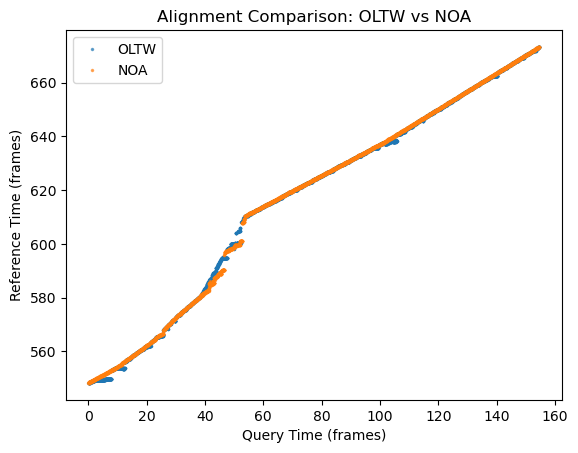

In [51]:
import matplotlib.pyplot as plt
plt.plot(trying1[0], trying1[1], '.', label='OLTW', alpha=0.6, markersize=3)
plt.plot(trying2[0], trying2[1], '.', label='NOA', alpha=0.6, markersize=3)
plt.xlabel('Query Time (frames)')
plt.ylabel('Reference Time (frames)')
plt.title('Alignment Comparison: OLTW vs NOA')
plt.legend()